## Notebook Overview

In this notebook, the classification approach was redesigned. The dataset is used in its original imbalanced form, without applying undersampling to ISUP grade 0. The original ISUP grades (0–5) are converted into a binary classification task, where:

- Class 0: ISUP 0–2 (non‑significant or lower‑grade cancer)
- Class 1: ISUP 3–5 (clinically significant cancer)

To avoid information leakage, SMOTE is applied only within the training folds of the nested cross‑validation. Before model training, a univariate feature‑selection step is performed on the full dataset using the Mann–Whitney U test, followed by Benjamini–Hochberg correction to control the false discovery rate (FDR). Only statistically significant features are retained for modelling.

- The following classification models are evaluated:
   - Logistic Regression  
   - K‑Nearest Neighbors  
   - Random Forest  
   - XGBoost  
   - LightGBM  
   - CatBoost  
   - Support Vector Machine  
   - Gaussian Process Classifier  


- To obtain robust and unbiased performance estimates, we perform nested cross‑validation, specifically:
  - 5‑fold outer CV for model evaluation  
  - 5‑fold inner CV for hyperparameter optimization using Optuna

- For each outer fold, the best hyperparameters are selected and the model is retrained before testing  

- The evaluation metrics used for each model include:

   - ROC curves for each model  
   - Combined ROC comparison  
   - Summary metrics produced by the evaluator


In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu, false_discovery_control

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import (
    RBF,
    Matern,
    WhiteKernel,
    ConstantKernel as C
)

from optuna.distributions import (
    FloatDistribution,
    IntDistribution,
    CategoricalDistribution
)

from deep_gp.preprocessing_data_2 import load_data
from deep_gp.evaluation import CVEvaluator


In [2]:
data = load_data(
    features_path="../../data/features.csv",
    targets_path="../../data/targets.csv"
)
print("Original dataset — samples per ISUP class:")
print(data["case_ISUP"].value_counts().sort_index())

# Features and original ISUP labels (undersampling happens inside CV)
X = data.drop(columns=['study_id', 'patient_id', 'case_ISUP']).reset_index(drop=True)
y_isup = data['case_ISUP'].reset_index(drop=True)

# Binary target: 1 = clinically significant (ISUP ≥ 3)
y = (y_isup >= 3).astype(int)
print("\nBinary target (0 = ISUP 0–2, 1 = ISUP 3–5):")
print(y.value_counts().sort_index())


Original dataset — samples per ISUP class:
case_ISUP
0    589
1    157
2    154
3     69
4     27
5     35
Name: count, dtype: int64

Binary target (0 = ISUP 0–2, 1 = ISUP 3–5):
case_ISUP
0    900
1    131
Name: count, dtype: int64


## Feature Selection via Mann-Whitney U Test with Benjamini-Hochberg Correction

Before training any classifier, we perform univariate feature selection to identify which radiomic features carry statistically significant discriminative signal between the two classes (ISUP 0–2 vs ISUP 3–5).

### Mann-Whitney U Test

For each feature, we apply the **Mann-Whitney U test** (also known as the Wilcoxon rank-sum test) — a non-parametric test that assesses whether the distributions of a feature differ significantly between the two groups. It is preferred over the t-test here because:

- Radiomic features are generally not normally distributed
- It is robust to outliers and skewed distributions

### The Multiple Testing Problem

Testing ~107 features independently inflates the probability of false positives. With a significance threshold of $\alpha = 0.05$, we expect roughly $0.05 \times 107 \approx 5$ features to appear significant purely by chance.

### Benjamini-Hochberg (BH) Correction

To control the **False Discovery Rate (FDR)** — the expected proportion of false positives among all rejected hypotheses — we apply the **Benjamini-Hochberg procedure**. Unlike the more conservative Bonferroni correction (which controls the family-wise error rate), BH is better suited to high-dimensional settings where we want to retain power while limiting false discoveries.

The procedure ranks the $m$ raw p-values $p_{(1)} \leq p_{(2)} \leq \cdots \leq p_{(m)}$ and rejects hypothesis $H_{(i)}$ if:

$$p_{(i)} \leq \frac{i}{m} \cdot q$$

where $q = 0.05$ is the desired FDR level. Features with a BH-corrected p-value below 0.05 are retained for modelling.


In [3]:
# Mann-Whitney U test for each feature

pvals = {}
for col in X.columns:
    _, p = mannwhitneyu(X.loc[y == 0, col], X.loc[y == 1, col])
    pvals[col] = p

pvals_series = pd.Series(pvals)

# Benjamini-Hochberg correction
bh_pvals = false_discovery_control(pvals_series.values, method="bh")
bh_series = pd.Series(bh_pvals, index=pvals_series.index)

results = pd.DataFrame({
    "p_raw": pvals_series,
    "p_bh": bh_series,
    "significant": bh_series < 0.05,
}).sort_values("p_raw")

print(
    "Features significant after BH correction (FDR < 0.05): "
    f"{results['significant'].sum()} / {len(results)}\n"
)
print(results[results["significant"]].to_string())

# Filter X to significant features only
significant_features = results.index[results["significant"]].tolist()
X_filtered = X[significant_features]


Features significant after BH correction (FDR < 0.05): 21 / 107

                                           p_raw      p_bh  significant
original_shape_SurfaceVolumeRatio       0.000008  0.000905         True
original_shape_MeshVolume               0.000033  0.001172         True
original_shape_VoxelVolume              0.000033  0.001172         True
original_shape_MinorAxisLength          0.000062  0.001172         True
original_shape_Maximum3DDiameter        0.000066  0.001172         True
original_shape_Maximum2DDiameterRow     0.000070  0.001172         True
original_shape_LeastAxisLength          0.000077  0.001172         True
original_shape_SurfaceArea              0.000088  0.001172         True
original_shape_MajorAxisLength          0.000129  0.001537         True
original_shape_Maximum2DDiameterSlice   0.000183  0.001954         True
original_glszm_GrayLevelNonUniformity   0.000276  0.002685         True
original_shape_Maximum2DDiameterColumn  0.000876  0.007814         True

In [4]:
pos_weight = int((y == 0).sum() / (y == 1).sum())

base_models = {
    
    "Logistic Regression": ImbPipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif)),
        ("smote", SMOTE(k_neighbors=3, random_state=42)),
        ("clf", LogisticRegression(solver="saga", class_weight="balanced", max_iter=30000, tol=1e-4))
    ]),

    "KNN": ImbPipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif)),
        ("smote", SMOTE(k_neighbors=3, random_state=42)),
        ("clf", KNeighborsClassifier())
    ]),

    "Random Forest": ImbPipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif)),
        ("smote", SMOTE(k_neighbors=3, random_state=42)),
        ("clf", RandomForestClassifier(class_weight="balanced", random_state=42))
    ]),

    "XGBoost": ImbPipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif)),
        ("smote", SMOTE(k_neighbors=3, random_state=42)),
        ("clf", XGBClassifier(scale_pos_weight=pos_weight, tree_method="hist", eval_metric="logloss", random_state=42))
    ]),

    "LightGBM": ImbPipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif)),
        ("smote", SMOTE(k_neighbors=3, random_state=42)),
        ("clf", LGBMClassifier(class_weight="balanced", random_state=42, verbose=-1))
    ]),

    "CatBoost": ImbPipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif)),
        ("smote", SMOTE(k_neighbors=3, random_state=42)),
        ("clf", CatBoostClassifier(auto_class_weights="Balanced", random_state=42, verbose=0))
    ]),

    "SVM": ImbPipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif)),
        ("smote", SMOTE(k_neighbors=3, random_state=42)),
        ("clf", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42))
    ]),

    "Gaussian Process": ImbPipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif)),
        ("smote", SMOTE(k_neighbors=3, random_state=42)),
        ("clf", GaussianProcessClassifier(
            kernel=C(1.0, (1e-6, 1e6)) * RBF(1.0, (1e-6, 1e6)) + WhiteKernel(1e-3, (1e-10, 1e1)),
            n_restarts_optimizer=3,
            random_state=42
        ))
    ]),
}

param_grids = {
    
    "Logistic Regression": {
        "select__k": CategoricalDistribution([10, 15, 20, 25]),
        "clf__C":    FloatDistribution(1e-3, 10.0, log=True),
    },
    
    "KNN": {
        "select__k":        CategoricalDistribution([10, 15, 20, 25]),
        "clf__n_neighbors": CategoricalDistribution([3, 5, 7, 9]),
        "clf__weights":     CategoricalDistribution(["uniform", "distance"]),
    },
    
    "Random Forest": {
        "select__k":              CategoricalDistribution([10, 15, 20, 25]),
        "clf__n_estimators":      IntDistribution(100, 500),
        "clf__max_depth":         CategoricalDistribution([None, 5, 10, 20]),
        "clf__min_samples_split": IntDistribution(2, 10),
        "clf__min_samples_leaf":  IntDistribution(1, 4),
        "clf__max_features":      CategoricalDistribution(["sqrt", "log2", None]),
    },
    
    "XGBoost": {
        "select__k":             CategoricalDistribution([10, 15, 20, 25]),
        "clf__n_estimators":     IntDistribution(100, 400),
        "clf__learning_rate":    FloatDistribution(0.01, 0.3, log=True),
        "clf__max_depth":        IntDistribution(3, 6),
        "clf__subsample":        FloatDistribution(0.7, 1.0),
        "clf__colsample_bytree": FloatDistribution(0.7, 1.0),
    },
    
    "LightGBM": {
        "select__k":             CategoricalDistribution([10, 15, 20, 25]),
        "clf__n_estimators":     IntDistribution(100, 400),
        "clf__learning_rate":    FloatDistribution(0.01, 0.3, log=True),
        "clf__max_depth":        CategoricalDistribution([-1, 5, 10, 20]),
        "clf__num_leaves":       IntDistribution(15, 63),
        "clf__subsample":        FloatDistribution(0.7, 1.0),
        "clf__colsample_bytree": FloatDistribution(0.7, 1.0),
    },
    
    "CatBoost": {
        "select__k":          CategoricalDistribution([10, 15, 20, 25]),
        "clf__iterations":    IntDistribution(100, 400),
        "clf__learning_rate": FloatDistribution(0.01, 0.3, log=True),
        "clf__depth":         IntDistribution(4, 10),
        "clf__l2_leaf_reg":   FloatDistribution(1.0, 10.0, log=True),
    },
    
    "SVM": {
        "select__k":  CategoricalDistribution([10, 15, 20, 25]),
        "clf__C":     FloatDistribution(0.1, 10.0, log=True),
        "clf__gamma": CategoricalDistribution(["scale", "auto"]),
    },
    
    "Gaussian Process": {
        "select__k": CategoricalDistribution([10, 15, 20, 25]),
        "clf__kernel": CategoricalDistribution([
            C(1.0, (1e-6, 1e6)) * RBF(1.0, (1e-6, 1e6)) + WhiteKernel(1e-3, (1e-10, 1e1)),
            C(1.0, (1e-6, 1e6)) * RBF(1.0, (1e-6, 1e6)),
            C(1.0, (1e-6, 1e6)) * Matern(1.0, (1e-6, 1e6), nu=1.5) + WhiteKernel(1e-3, (1e-10, 1e1)),
            C(1.0, (1e-6, 1e6)) * Matern(1.0, (1e-6, 1e6), nu=1.5),
            C(1.0, (1e-6, 1e6)) * Matern(1.0, (1e-6, 1e6), nu=2.5) + WhiteKernel(1e-3, (1e-10, 1e1)),
            C(1.0, (1e-6, 1e6)) * Matern(1.0, (1e-6, 1e6), nu=2.5),
        ]),
    },
    
}



=== Feature set: All Features — SelectKBest + No Undersampling ===

=== Evaluation: Logistic Regression ===


Outer CV (Logistic Regression): 100%|██████████| 5/5 [00:13<00:00,  2.76s/it]


╭───────────────────────────────────────── Best Hyperparameters per Fold ─────────────────────────────────────────╮
│                                                                                                                 │
│   Fold     Best Parameters                                                                                      │
│  ─────────────────────────────────────────────────────────────                                                  │
│   1        {'select__k': 25, 'clf__C': 0.055031208822580766}                                                    │
│   2        {'select__k': 25, 'clf__C': 0.0182712318179038}                                                      │
│   3        {'select__k': 20, 'clf__C': 0.0010714819433962105}                                                   │
│   4        {'select__k': 25, 'clf__C': 4.42188841545927}                                                        │
│   5        {'select__k': 25, 'clf__C': 5.649656828677129}                                                       │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────────── Metrics ────────────────────────────────────────────────────╮
│                                                                                                                 │
│   Metric                 Value                                                                                  │
│  ──────────────────────────────                                                                                 │
│   Accuracy               0.578                                                                                  │
│   ROC-AUC                0.584                                                                                  │
│   Mean Uncertainty       0.866                                                                                  │
│   Uncertainty (Pred=0)   0.816                                                                                  │
│   Uncertainty (Pred=1)   0.933                                                                                  │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── Confusion Matrix ────────────────────────────────────────────────╮
│                                                                                                                 │
│            Pred 0   Pred 1                                                                                      │
│  ──────────────────────────                                                                                     │
│   True 0      528      372                                                                                      │
│   True 1       63       68                                                                                      │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

Outer CV (Gaussian Process):  60%|██████    | 3/5 [1:55:15<1:16:41, 2300.51s/it]/home/arampatzis/projects/anastasiadou/.venv/lib/python3.11/site-packages/sklearn/gaussian_process/_gpc.py:485: RuntimeWarning: overflow encountered in exp
  - np.log1p(np.exp(-(self.y_train_ * 2 - 1) * f)).sum()
/home/arampatzis/projects/anastasiadou/.venv/lib/python3.11/site-packages/sklearn/gaussian_process/_gpc.py:485: RuntimeWarning: overflow encountered in exp
  - np.log1p(np.exp(-(self.y_train_ * 2 - 1) * f)).sum()
/home/arampatzis/projects/anastasiadou/.venv/lib/python3.11/site-packages/sklearn/gaussian_process/_gpc.py:485: RuntimeWarning: overflow encountered in exp
  - np.log1p(np.exp(-(self.y_train_ * 2 - 1) * f)).sum()
/home/arampatzis/projects/anastasiadou/.venv/lib/python3.11/site-packages/sklearn/gaussian_process/_gpc.py:485: RuntimeWarning: overflow encountered in exp
  - np.log1p(np.exp(-(self.y_train_ * 2 - 1) * f)).sum()
Outer CV (Gaussian Process): 100%|██████████| 5/5 [3:20:08<00:00, 24

╭───────────────────────────────────────── Best Hyperparameters per Fold ─────────────────────────────────────────╮
│                                                                                                                 │
│   Fold     Best Parameters                                                                                      │
│  ─────────────────────────────────────────────────────────────────────────────────────────────────────────────  │
│   1        {'select__k': 25, 'clf__kernel': 1**2 * Matern(length_scale=1, nu=1.5) +                             │
│            WhiteKernel(noise_level=0.001)}                                                                      │
│   2        {'select__k': 25, 'clf__kernel': 1**2 * Matern(length_scale=1, nu=1.5) +                             │
│            WhiteKernel(noise_level=0.001)}                                                                      │
│   3        {'select__k': 15, 'clf__kernel': 1**2 * Matern(length_scale=1, nu=1.5) +                             │
│            WhiteKernel(noise_level=0.001)}                                                                      │
│   4        {'select__k': 15, 'clf__kernel': 1**2 * Matern(length_scale=1, nu=1.5) +                             │
│            WhiteKernel(noise_level=0.001)}                                                                      │
│   5        {'select__k': 25, 'clf__kernel': 1**2 * Matern(length_scale=1, nu=1.5)}                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────────── Metrics ────────────────────────────────────────────────────╮
│                                                                                                                 │
│   Metric                 Value                                                                                  │
│  ──────────────────────────────                                                                                 │
│   Accuracy               0.795                                                                                  │
│   ROC-AUC                0.548                                                                                  │
│   Mean Uncertainty       0.861                                                                                  │
│   Uncertainty (Pred=0)   0.849                                                                                  │
│   Uncertainty (Pred=1)   0.957                                                                                  │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── Confusion Matrix ────────────────────────────────────────────────╮
│                                                                                                                 │
│            Pred 0   Pred 1                                                                                      │
│  ──────────────────────────                                                                                     │
│   True 0      805       95                                                                                      │
│   True 1      116       15                                                                                      │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────── Classification Report (Gaussian Process) ────────────────────────────────────╮
│                                                                                                                 │
│   Class          Precision   Recall   F1-Score   Support                                                        │
│  ────────────────────────────────────────────────────────                                                       │
│   0                  0.874    0.894      0.884       900                                                        │
│   1                  0.136    0.115      0.124       131                                                        │
│   macro avg          0.505    0.504      0.504      1031                                                        │
│   weighted avg       0.780    0.795      0.788      1031                                                        │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

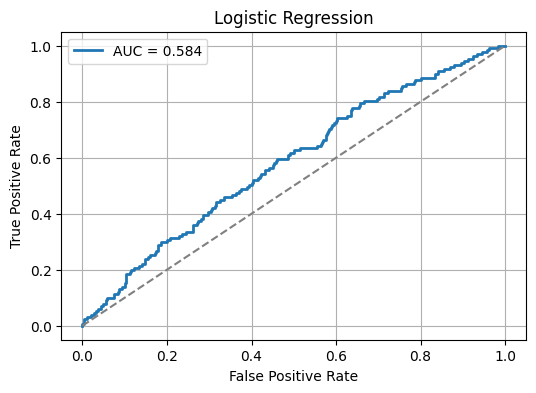

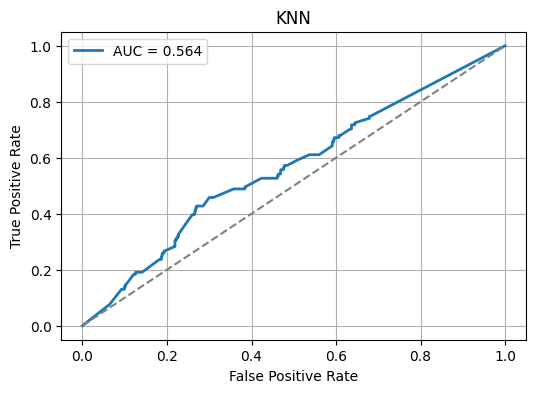

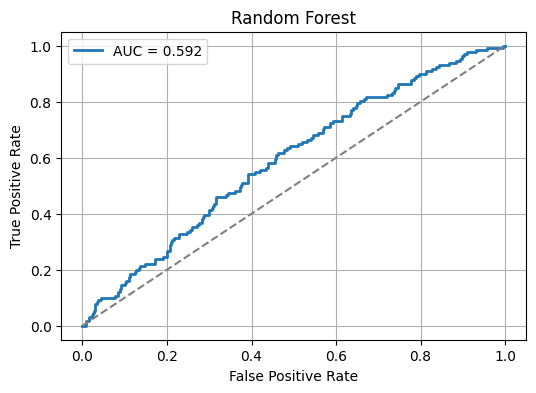

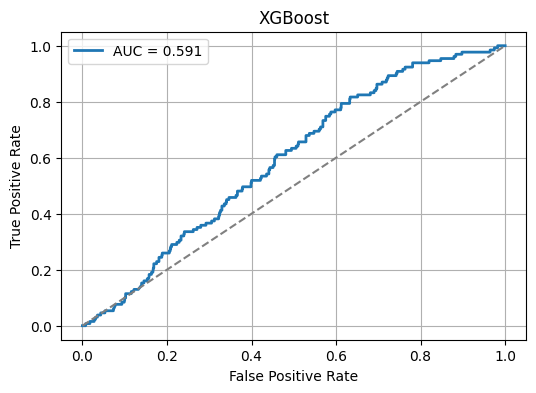

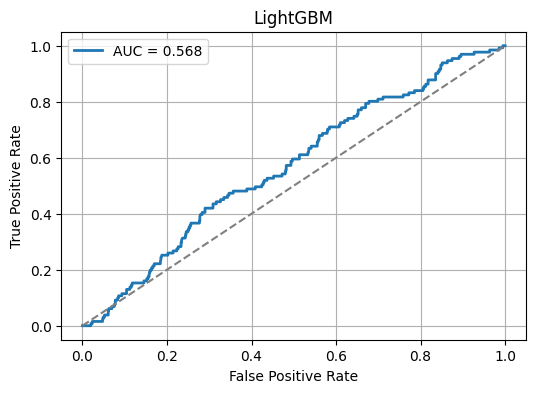

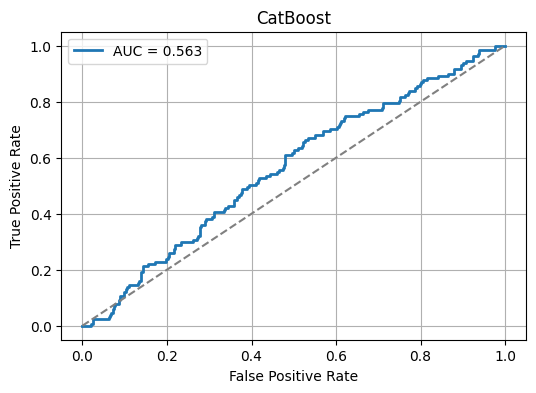

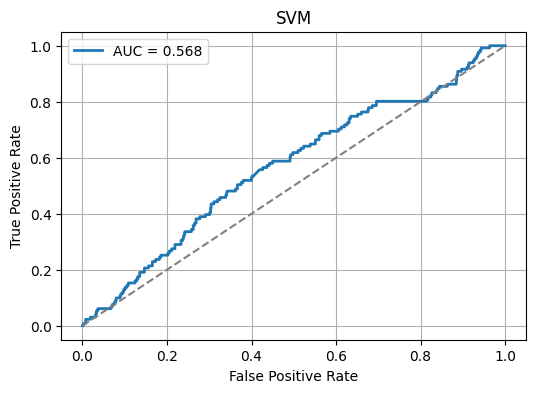

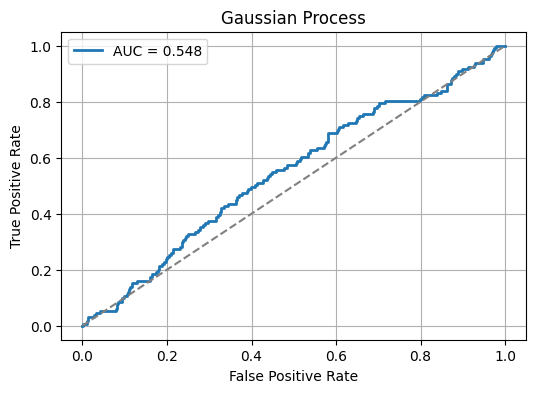

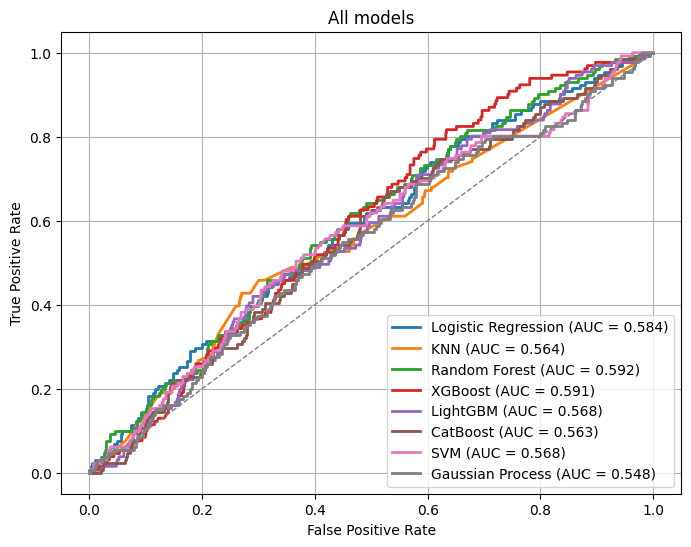

,Model,Accuracy,ROC-AUC,Mean Uncertainty,Uncertainty (Pred=0),Uncertainty (Pred=1)
0,Logistic Regression,0.578080,0.584360,0.866083,0.815974,0.933387
1,KNN,0.600388,0.563626,0.509842,0.390129,0.691900
2,Random Forest,0.680892,0.591917,0.788582,0.720550,0.960760
3,XGBoost,0.450048,0.591170,0.733836,0.738934,0.730671
4,LightGBM,0.710960,0.567824,0.640617,0.562557,0.896500
5,CatBoost,0.707081,0.562561,0.653683,0.578516,0.892269
6,SVM,0.532493,0.567604,0.772026,0.621235,0.926668
7,Gaussian Process,0.795344,0.547710,0.860851,0.849308,0.957495


,Model,Accuracy,ROC-AUC,Mean Uncertainty,Uncertainty (Pred=0),Uncertainty (Pred=1)
0,Logistic Regression,0.578080,0.584360,0.866083,0.815974,0.933387
1,KNN,0.600388,0.563626,0.509842,0.390129,0.691900
2,Random Forest,0.680892,0.591917,0.788582,0.720550,0.960760
3,XGBoost,0.450048,0.591170,0.733836,0.738934,0.730671
4,LightGBM,0.710960,0.567824,0.640617,0.562557,0.896500
5,CatBoost,0.707081,0.562561,0.653683,0.578516,0.892269
6,SVM,0.532493,0.567604,0.772026,0.621235,0.926668
7,Gaussian Process,0.795344,0.547710,0.860851,0.849308,0.957495


In [5]:
evaluator = CVEvaluator(
    base_models=base_models,
    param_grids=param_grids,
    n_jobs=10,
    n_trials=30,
    undersample=False,
)
evaluator.fit(X, y, y_isup, label="All Features — SelectKBest + No Undersampling")
evaluator.plot_roc_curves()
evaluator.plot_combined_roc()
evaluator.summary()
